In [ ]:
import pandas as pd

chunks = pd.read_csv("../data/raw/archive/books_rating.csv",
                     usecols=["Title", "review/score", "review/text"],
                     chunksize=200_000)

parts = []
for chunk in chunks:
    chunk = chunk.dropna(subset=["Title", "review/score", "review/text"])
    parts.append(chunk.sample(frac=0.03, random_state=42))

df = pd.concat(parts, ignore_index=True)
df = df.rename(columns={"review/score": "score", "review/text": "text", "Title": "title"})

print(df.shape)
print(df.head())
print(df["score"].value_counts().sort_index())

df.to_csv("../data/processed/sample.csv", index=False)

(89994, 3)
                                               title  score  \
0        American Statesmen on Slavery and the Negro    2.0   
1                                     The Two Towers    5.0   
2  Los Principios del Exito : Como Llegar de Dond...    5.0   
3                                      Monte Cristo,    5.0   
4               Of Mice and Men (Penguin Audiobooks)    3.0   

                                                text  
0  Basically, this book shows that most of Americ...  
1  The Two Towers includes book III and IV in the...  
2  Este libro es maravilloso. Jack Canfield da pr...  
3  Having never read The Count of Monte Cristo an...  
4  I think the story is action packed. Where Lenn...  
score
1.0     6233
2.0     4589
3.0     7538
4.0    17488
5.0    54146
Name: count, dtype: int64


In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../data/processed/sample.csv")

df = df.drop_duplicates(subset="text")
df["n_words"] = df["text"].str.split().str.len()
print(df["n_words"].describe())
df = df[df["n_words"] >= 5]
print(df.shape)

Matplotlib is building the font cache; this may take a moment.


count    87363.000000
mean       143.264071
std        163.153192
min          1.000000
25%         48.000000
50%         93.000000
75%        177.000000
max       5785.000000
Name: n_words, dtype: float64
(87312, 4)


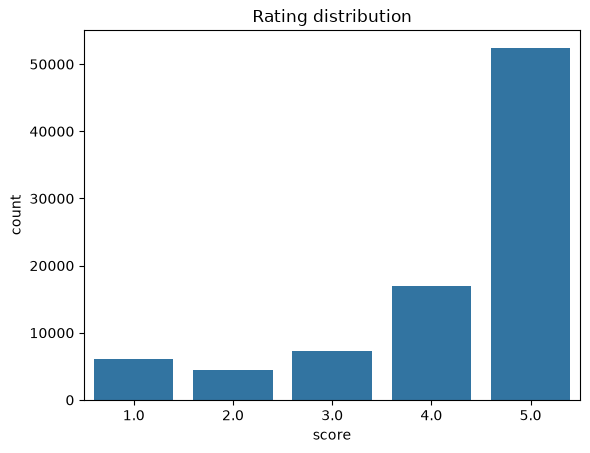

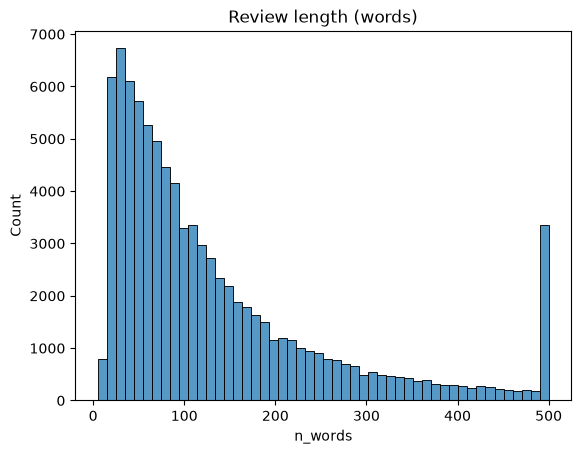

In [4]:
sns.countplot(x="score", data=df)
plt.title("Rating distribution"); plt.show()

sns.histplot(df["n_words"].clip(upper=500), bins=50)
plt.title("Review length (words)"); plt.show()

In [5]:
from langdetect import detect, DetectorFactory
DetectorFactory.seed = 0

def is_english(t):
    try:
        return detect(t[:300]) == "en"
    except Exception:
        return False

df["is_en"] = df["text"].map(is_english)
print(df["is_en"].value_counts())
df = df[df["is_en"]]

is_en
True     87135
False      177
Name: count, dtype: int64


In [6]:
df = df[df["score"] != 3].copy()
df["label"] = (df["score"] >= 4).astype(int)
print(df["label"].value_counts(normalize=True))
print(df.groupby("label")["n_words"].median())

df.to_csv("../data/processed/eda_clean.csv", index=False)

label
1    0.867709
0    0.132291
Name: proportion, dtype: float64
label
0    100.0
1     89.0
Name: n_words, dtype: float64


In [7]:
for lab in [0, 1]:
    print("LABEL", lab)
    for t in df[df["label"] == lab]["text"].sample(4, random_state=1):
        print("-", t[:300], "\n")

LABEL 0
- I decided to read this book after seeing the movie with Vincent Price and George Sanders on TCM. It wasn't bad. Usually the book is more informative and entertaining than the movie. For example, "To Kill a Mockingbird" was a great movie, but the book was even better. Hawthorne seems to go on and on  

- Whether you've read TSH or not, you'll quickly realize that Donna Tartt is an extraordinary writer. And therein lies the problem. So much of this overlong novel is composed of gorgeous, glittering vignettes that vividly capture the life of its protagonist Harriet and the world she lives in in tiny A 

- Matilda is a five year old girl who has parents who don't know her intelligence. Matilda has gone to the library since she was four years old. She read all the childen's books in the library. When Matilda started, she was five years old.Miss Honey is her teacher.When Matilda started school, she lear 

- Like previous users have mentioned, this book is very hard to follow. They 